## Agent

In [1]:
import tarfile
import pandas as pd
import re
import pickle

def extract_tar_metrics(tar_path: str) -> pd.DataFrame:
    """
    Extract timing and token usage from pickle files inside a tar archive.

    Parameters:
        tar_path (str): Path to the .tar file.

    Returns:
        pd.DataFrame: DataFrame with columns:
            ['cve', 'commit_id', 'input_tokens', 'output_tokens', 'total_tokens', 'duration']
    """
    results = []

    with tarfile.open(tar_path, "r") as tar:
        for member in tar.getmembers():
            if not member.name.endswith(".pkl"):
                continue

            # Parse filename: e.g. './CVE-2019-5484_5eed363e102856b8bfb2884dbb173b973a977860.pkl'
            match = re.search(r"CVE-\d{4}-\d+_([0-9a-f]+)\.pkl", member.name)
            if not match:
                continue

            cve = member.name.split("_")[0].split("/")[-1]  # 'CVE-2019-5484'
            commit_id = match.group(1)

            f = tar.extractfile(member)
            if f is None:
                continue

            # Load pickle
            try:
                data = pickle.load(f)
            except Exception as e:
                print(f"Error loading {member.name}: {e}")
                continue

            # Extract metrics
            try:
                token_usage = data.token_usage
                timing = data.timing
                results.append({
                    "cve": cve,
                    "commit_id": commit_id,
                    "input_tokens": token_usage.input_tokens,
                    "output_tokens": token_usage.output_tokens,
                    "total_tokens": token_usage.total_tokens,
                    "duration": timing.duration
                })
            except Exception as e:
                print(f"Missing fields in {member.name}: {e}")

    return pd.DataFrame(results)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path('../data/')


In [3]:
subsets = {
    'PatchFinder_top10': '\\textsc{PatchFinder\\textsubscript{top10}}',
    'random_10': '\\textsc{Random\\textsubscript{10}}',
}

models = {
    "codebert": "CodeBERT",
    "codereviewer": "CodeReviewer",
    "Llama-3.3-70B-Instruct": "Llama-3.3-70B-Instruct",
    "Qwen3-235B-A22B-Instruct-2507": "Qwen3-235B-A22B-Instruct-2507",
    "DeepSeek-Coder-V2-Lite-Instruct": "DeepSeek-Coder-V2-Lite-Instruct",
    "gemma-3-27b-it": "gemma-3-27b-it",
}

approaches = {
    'VulFixMiner': 'VulFixMiner',
    'PatchFinder': 'PatchFinder',
    'LLM4VFD': 'LLM4VFD',
    'CommitShield': 'CommitShield',
    'agent': 'Agent',
}

In [113]:
#get all jsonl files in data/output

import os
import json
import pandas as pd
from tqdm import tqdm

jsonl_files = [DATA_DIR / "output" / f for f in os.listdir(DATA_DIR / "output") if f.endswith(".tar")]

data = []
for file in tqdm(jsonl_files):
    print(file)
    split = file.name.split("_")
    subset = "_".join(split[0:2])
    model = "_".join(split[2:]).replace(".jsonl", "")
    print(f"Model: {model}, Subset: {subset}")
    
    df = extract_tar_metrics(file)
    print(df["input_tokens"].mean())
    print(df["output_tokens"].mean())
    print(df["total_tokens"].mean())
    print(df["duration"].mean() / 60 / 60)
    
    data.append({
        "model": model,
        "subset": subset,
        "input_tokens": df["input_tokens"].mean(),
        "output_tokens": df["output_tokens"].mean(),
        "total_tokens": df["total_tokens"].mean(),
        "duration": df["duration"].mean()
    })
        

    #calc cost

  0%|          | 0/6 [00:00<?, ?it/s]

../data/output/random_10_Llama-3.3-70B-Instruct.tar
Model: Llama-3.3-70B-Instruct.tar, Subset: random_10


 17%|█▋        | 1/6 [00:03<00:18,  3.80s/it]

22372.145641274463
553.4966844573831
22925.642325731846
0.006682755582316158
../data/output/random_10_Qwen3-235B-A22B-Instruct-2507.tar
Model: Qwen3-235B-A22B-Instruct-2507.tar, Subset: random_10


 33%|███▎      | 2/6 [00:12<00:26,  6.72s/it]

...

94787.11741872877
1530.788452207666
96317.90587093643
0.006125317307869837
../data/output/PatchFinder_top10_gemma-3-27b-it.tar
Model: gemma-3-27b-it.tar, Subset: PatchFinder_top10


 83%|████████▎ | 5/6 [00:34<00:06,  6.97s/it]

80810.70477783975
1057.8430005577245
81868.54777839748
0.0032126016037384015
../data/output/PatchFinder_top10_Llama-3.3-70B-Instruct.tar
Model: Llama-3.3-70B-Instruct.tar, Subset: PatchFinder_top10


100%|██████████| 6/6 [00:37<00:00,  6.28s/it]

22879.28944179659
540.0733500282737
23419.362791824864
0.00651816874855125


In [115]:
df = pd.DataFrame(data)
df

,model,subset,input_tokens,output_tokens,total_tokens,duration
0,Llama-3.3-70B-Instruct.tar,random_10,22372.145641,553.496684,22925.642326,24.057920
1,Qwen3-235B-A22B-Instruct-2507.tar,random_10,81701.242645,1461.586890,83162.829534,22.547171
2,gemma-3-27b-it.tar,random_10,69478.937998,990.727990,70469.665989,10.991543
3,Qwen3-235B-A22B-Instruct-2507.tar,PatchFinder_top10,94787.117419,1530.788452,96317.905871,22.051142
4,gemma-3-27b-it.tar,PatchFinder_top10,80810.704778,1057.843001,81868.547778,11.565366
5,Llama-3.3-70B-Instruct.tar,PatchFinder_top10,22879.289442,540.073350,23419.362792,23.465407


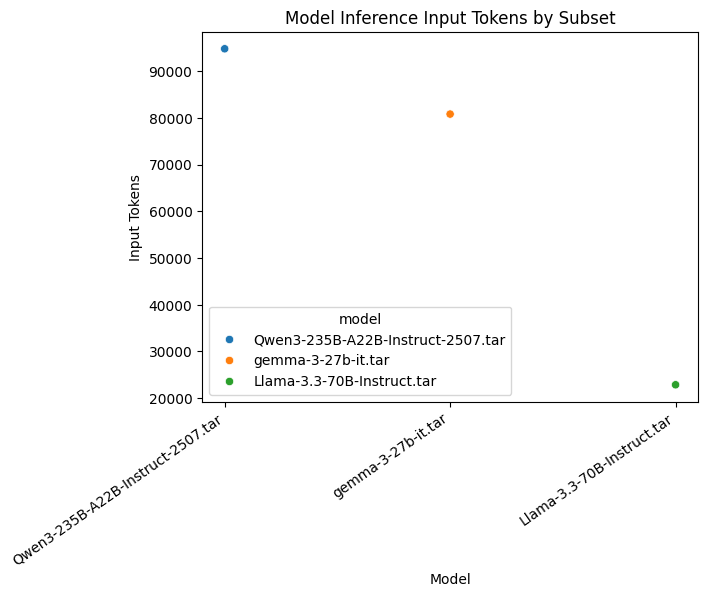

In [120]:
# plot
import matplotlib.pyplot as plt
import seaborn as sns
#bar plot with models on x axis and tokens on y axis, grouped by subset
#x=duration, y= input_tokens, model = color, and shape by subset
sns.scatterplot(x="model", y="input_tokens", hue="model", data=df[df["subset"] == "PatchFinder_top10"])
#sns.barplot(data=df, x="model", y="input_tokens", hue="subset
plt.title("Model Inference Input Tokens by Subset")
plt.xlabel("Model")
plt.ylabel("Input Tokens")
#rotate x axis labels 45 degrees and anchor to the right
plt.xticks(rotation=35, ha="right")
plt.show()

In [132]:
df.to_csv(DATA_DIR / "token_usage_agent.csv", index=False)

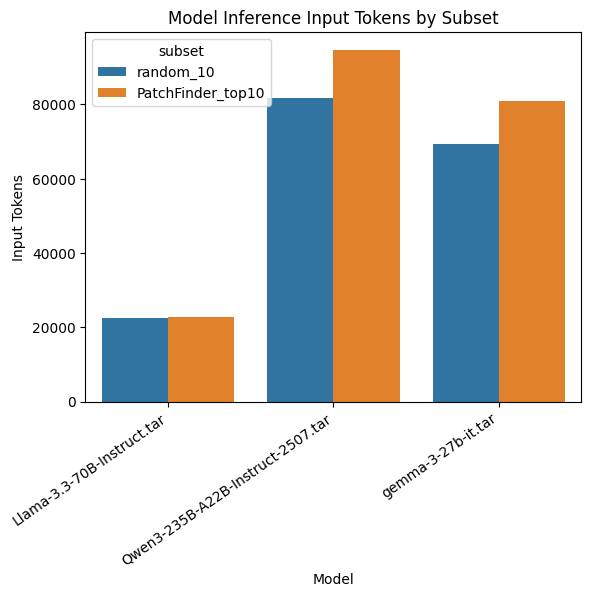

In [14]:
# plot
import matplotlib.pyplot as plt
import seaborn as sns
#bar plot with models on x axis and tokens on y axis, grouped by subset

sns.barplot(data=df, x="model", y="input_tokens", hue="subset")
plt.title("Model Inference Input Tokens by Subset")
plt.xlabel("Model")
plt.ylabel("Input Tokens")
#rotate x axis labels 45 degrees and anchor to the right
plt.xticks(rotation=35, ha="right")
plt.show()

# LLM4VFD

In [10]:
data_path = DATA_DIR / "baselines" / "LLM4VFD" / "output"
data = []
for fname in os.listdir(data_path):
    subset = "_".join(fname.split("_")[0:2])
    model = "_".join(fname.split("_")[2:]).replace(".jsonl", "")
    if fname.endswith(".jsonl"):
        print(fname)

        # Read CSV
        
        raw_data = []
        with open(data_path / fname, 'r') as f:
            lines = f.readlines()
            for line in lines:
                record = json.loads(line)
                d = {
                    "subset": subset,
                    "model": model,
                    "input_tokens": record["metadata"]["usage"]["input_tokens"],
                    "output_tokens": record["metadata"]["usage"]["output_tokens"],
                    "embedding_tokens": record["metadata"]["usage"].get("embedding_tokens", 0),
                }
                d["total_tokens"] = d["input_tokens"] + d["output_tokens"] + d["embedding_tokens"]
                raw_data.append(d)
        df = pd.DataFrame(raw_data)
        print(df["input_tokens"].mean())
        print(df["output_tokens"].mean())
        print(df["total_tokens"].mean())
        
        data.append({
            "model": model,
            "subset": subset,
            "input_tokens": df["input_tokens"].mean(),
            "output_tokens": df["output_tokens"].mean(),
            "embedding_tokens": df["embedding_tokens"].mean(),
            "total_tokens": df["total_tokens"].mean(),
        })
df = pd.DataFrame(data)

PatchFinder_top10_Llama-3.3-70B-Instruct.jsonl
5772.856661228929
539.3695486677542
6640.401413811855
random_10_Llama-3.3-70B-Instruct.jsonl
5327.522292993631
528.4800955414013
6178.835489649681
PatchFinder_top10_Qwen3-235B-A22B-Instruct-2507.jsonl
6409.641515492053
746.6736233745385
7510.902793385776
random_10_gemma-3-27b-it.jsonl
5032.339809022062
1883.087751070135
7295.500905498848
PatchFinder_top10_gemma-3-27b-it.jsonl
7185.188438378162
740.8321959052589
8327.84841429145
random_10_Qwen3-235B-A22B-Instruct-2507.jsonl
5745.342657342658
707.8118318463146
6790.080379390724


In [11]:
df.to_csv(DATA_DIR / "token_usage_LLM4VFD.csv", index=False)

# CommitShield

In [8]:
import os
import json

data_path = DATA_DIR / "baselines" / "CommitShield" / "output"
data = []
for fname in os.listdir(data_path):
    subset = "_".join(fname.split("_")[0:2])
    model = "_".join(fname.split("_")[2:]).replace(".jsonl", "")
    if fname.endswith(".jsonl"):
        print(fname)

        # Read CSV
        
        raw_data = []
        with open(data_path / fname, 'r') as f:
            lines = f.readlines()
            for line in lines:
                record = json.loads(line)
                d = {
                    "subset": subset,
                    "model": model,
                    "input_tokens": record["metadata"]["usage"]["input_tokens"],
                    "output_tokens": record["metadata"]["usage"]["output_tokens"],
                }
                d["total_tokens"] = d["input_tokens"] + d["output_tokens"]
                raw_data.append(d)
        df = pd.DataFrame(raw_data)
        print(df["input_tokens"].mean())
        print(df["output_tokens"].mean())
        print(df["total_tokens"].mean())
        
        data.append({
            "model": model,
            "subset": subset,
            "input_tokens": df["input_tokens"].mean(),
            "output_tokens": df["output_tokens"].mean(),
            "total_tokens": df["total_tokens"].mean(),
        })
df = pd.DataFrame(data)

PatchFinder_top10_Llama-3.3-70B-Instruct.jsonl
8235.205832043659
1764.7944123157124
10000.000244359371
random_10_Llama-3.3-70B-Instruct.jsonl
6903.523663234806
1537.9166389903687
8441.440302225174
PatchFinder_top10_Qwen3-235B-A22B-Instruct-2507.jsonl
9337.406387930343
706.6505898403018
10044.056977770644
random_10_gemma-3-27b-it.jsonl
9039.462121212122
583.2549117549117
9622.717032967033
PatchFinder_top10_gemma-3-27b-it.jsonl
10415.970054520303
634.2236146146961
11050.193669134998
random_10_Qwen3-235B-A22B-Instruct-2507.jsonl
6042.431024797368
544.4003691517535
6586.831393949121


In [9]:
df.to_csv(DATA_DIR / "token_usage_CommitShield.csv", index=False)

# Plot

In [4]:
from pathlib import Path
DATA_DIR = Path("../data")


In [5]:
import os

# Prepend TeX bin path to the PATH environment variable
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

In [6]:

import matplotlib
import matplotlib.pyplot as plt

matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})

%matplotlib inline

<function LinearScale.__init__ at 0x112d74e00>
<function LogScale.__init__ at 0x112d758a0>
<function SymmetricalLogScale.__init__ at 0x112d76200>
<function AsinhScale.__init__ at 0x112d76980>
<function LogitScale.__init__ at 0x112d77100>
<function FuncScale.__init__ at 0x112d75260>
<function FuncScaleLog.__init__ at 0x112d75bc0>
<function Artist.get_agg_filter at 0x1131c09a0>
<function Artist.get_alpha at 0x1131c0180>
<function Artist.get_animated at 0x1131c02c0>
<function Artist.get_children at 0x113137420>
<function Artist.get_clip_box at 0x1131c0540>
<function Artist.get_clip_on at 0x1131c04a0>
<function Artist.get_clip_path at 0x1131c05e0>
<function Artist.get_cursor_data at 0x1131c1760>
<function Artist.get_figure at 0x113137ec0>
<function Artist.get_gid at 0x1131379c0>
<function Artist.get_in_layout at 0x1131c0360>
<function Artist.get_label at 0x1131c0ea0>
<function Artist.get_mouseover at 0x1131c18a0>
<function Artist.get_path_effects at 0x113137e20>
<function Artist.get_picker

In [7]:
approaches = {
    'LLM4VFD': 'LLM4VFD',
    'CommitShield': 'CommitShield',
    'agent': 'Agent',
}

In [8]:
import os
import pandas as pd


dfs = []
for fname in os.listdir(DATA_DIR):
    if fname.endswith(".csv") and fname.startswith("token_usage_"):
        # Extract the 'xxx' part
        approach = fname.replace("token_usage_", "").replace(".csv", "")
        
        # Read CSV
        df = pd.read_csv(os.path.join(DATA_DIR, fname))
        
        # Add new column
        df["approach"] = approach
        
        dfs.append(df)

# Optionally concatenate them all
data = pd.concat(dfs, ignore_index=True)

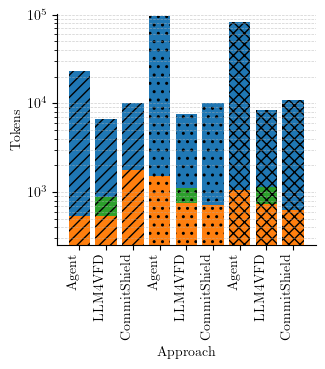

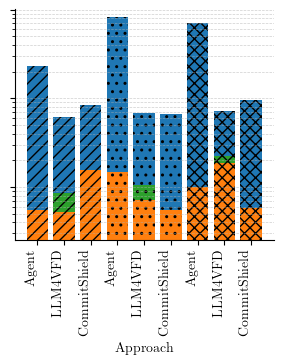

In [10]:
import matplotlib.pyplot as plt

# Ensure embedding_tokens has no NaN
df = data.copy()
df["embedding_tokens"] = df["embedding_tokens"].fillna(0)

# Expected columns:
# model, subset, input_tokens, output_tokens, embedding_tokens


subsets = ['PatchFinder_top10', 'random_10']
models = sorted(df["model"].unique())

hatches = ["///", "..", "xxx"]  # expand if needed
hatch_map = {model: hatches[i % len(hatches)] for i, model in enumerate(models)}

max_total = df["total_tokens"].max() * 1.05  # add 5% margin for aesthetics

for idx, subset in enumerate(subsets):
    
    df_sub = df[df["subset"] == subset].sort_values("model")

    x = range(len(df_sub))

    fig, ax = plt.subplots(figsize=(4, 3.2))
    hatches_for_bars = [hatch_map[m] for m in df_sub["model"]]
    ax.bar(
        x,
        df_sub["input_tokens"],
        hatch=hatches_for_bars,
        bottom=df_sub["output_tokens"] + df_sub["embedding_tokens"],
        label="Input Tokens"
    )
    ax.bar(x,  df_sub["output_tokens"], hatch=hatches_for_bars, label="Output Tokens")
    ax.bar(
        x,
        df_sub["embedding_tokens"],
        hatch=hatches_for_bars,
        bottom=df_sub["output_tokens"],
        label="Embedding Tokens"
    )

    ax.set_xticks(list(x))
    ax.set_xticklabels(df_sub["approach"].apply(lambda a: approaches[a]), rotation=90, ha="right")
    ax.set_ylim(250, max_total)  # set same y-axis for all plots (log scale, min>0)
    ax.set_yscale("log")

    ax.set_xlabel("Approach")
    #ax.set_title(f"Token Breakdown — {subset}")
    #ax.legend()
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6, which="both")

    # Only the first figure gets y-labels
    if idx == 0:
        ax.set_ylabel("Tokens")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])
       
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
        
    fig.set_size_inches(w=3.3374, h=(3))

    #fig.tight_layout()

    fig.savefig(f'../figures/token_usage_{subset}.pdf', bbox_inches='tight')
    fig.savefig(f'../figures/token_usage_{subset}.pgf', bbox_inches='tight')
    plt.show()
    
    

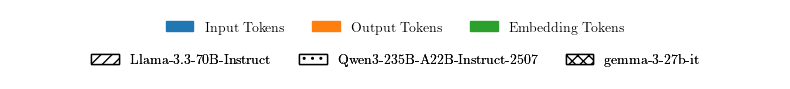

In [11]:

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# --- Token type legend (colors) ---
token_types = ["Input Tokens", "Output Tokens", "Embedding Tokens"]
colors = ["C0", "C1", "C2"]  # matplotlib default colors
token_patches = [mpatches.Patch(color=colors[i], label=token_types[i]) for i in range(3)]

# --- Model legend (hatch patterns) ---
model_patches = [
    mpatches.Patch(facecolor="white", edgecolor="black", hatch=hatch_map[m], label=m)
    for m in models
]

# --- Create dummy figure for combined legend ---
fig_legend = plt.figure(figsize=(8, 1))
ax = fig_legend.add_subplot(111)
ax.axis("off")

# First row: token type
legend1 = ax.legend(handles=token_patches, loc="upper center", ncol=len(token_patches), frameon=False)
ax.add_artist(legend1)

# Second row: models with hatch
legend2 = ax.legend(handles=model_patches, loc="lower center", ncol=len(model_patches), frameon=False)
ax.add_artist(legend2)

fig_legend.tight_layout()
fig_legend.savefig('../figures/token_usage_legend.pdf', bbox_inches='tight')
fig_legend.savefig('../figures/token_usage_legend.pgf', bbox_inches='tight')
plt.show()